In [2]:
!pip install seaborn

In [8]:
!pip install joblib

In [9]:
!pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.8/69.5 MB 2.7 MB/s eta 0:00:26
    --------------------------------------- 1.3/69.5 MB 2.5 MB/s eta 0:00:28
    --------------------------------------- 1.6/69.5 MB 2.2 MB/s eta 0:00:32
   - -------------------------------------- 1.8/69.5 MB 2.1 MB/s eta 0:00:33
   - -------------------------------------- 2.1/69.5 MB 2.0 MB/s eta 0:00:35
   - -------------------------------------- 2.6/69.5 MB 1.8 MB/s eta 0:00:38
   - -------------------------------------- 2.9/69.5 MB 1.8 MB/s eta 0:00:37
   - -------------------------------------- 3.4/69.5 MB 1.8 MB/s eta 0:00:36
   -- ------------------------------------- 3.7/69.5 MB 1.8 MB/s eta 0:00:38
   -- ------------------------------------- 4.2/69.5 MB 1.8 MB/s eta 0:00:36
   -- ------------------------------------- 4.7/69.5 MB 1.9 MB/s eta 0:00:35
   --- ------

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

In [10]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                              precision_recall_curve, roc_curve, f1_score, accuracy_score)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras import layers, models

sns.set(style="whitegrid")
print("Libraries loaded successfully.")


Libraries loaded successfully.


In [11]:
df = pd.read_csv("creditcard_demo.csv")
print("Shape:", df.shape)
df.head()

Shape: (8040, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,158894,-0.211606,-1.210163,-1.564917,1.484151,-0.728181,-0.948486,1.918881,-0.590198,-3.269663,...,1.335137,0.058691,-0.076196,-0.834501,-0.584118,0.268705,1.972889,0.356511,46.56,0
1,141108,1.959148,3.105687,-0.265131,-1.346928,2.259019,2.835574,-0.253193,-0.328021,-0.119867,...,0.173800,-1.164086,0.179303,-0.910720,-1.175640,1.746052,1.174316,-0.031909,38.66,0
2,153862,0.626717,-2.343434,0.079026,1.116736,-0.317205,-1.292727,-0.172531,0.101240,-2.090767,...,0.766191,-0.521317,-0.121457,2.220001,0.568365,0.603688,-0.722659,-0.283185,5.52,0
3,16370,-4.390800,1.929982,-0.113375,1.463589,-0.866683,-0.421860,-1.119411,-1.577985,-1.845783,...,-2.196098,0.934674,-1.855675,1.185050,1.573118,-0.424667,2.454760,2.556993,79.89,0
4,85065,-1.743064,-0.144514,-1.829628,-0.258008,-0.982072,-0.001199,-0.764494,-0.053970,0.903773,...,0.496476,1.326221,-0.179953,-1.963048,3.365868,-0.903966,-1.741384,1.075483,90.08,0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8040 entries, 0 to 8039
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    8040 non-null   int64  
 1   V1      8040 non-null   float64
 2   V2      8040 non-null   float64
 3   V3      8040 non-null   float64
 4   V4      8040 non-null   float64
 5   V5      8040 non-null   float64
 6   V6      8040 non-null   float64
 7   V7      8040 non-null   float64
 8   V8      8040 non-null   float64
 9   V9      8040 non-null   float64
 10  V10     8040 non-null   float64
 11  V11     8040 non-null   float64
 12  V12     8040 non-null   float64
 13  V13     8040 non-null   float64
 14  V14     8040 non-null   float64
 15  V15     8040 non-null   float64
 16  V16     8040 non-null   float64
 17  V17     8040 non-null   float64
 18  V18     8040 non-null   float64
 19  V19     8040 non-null   float64
 20  V20     8040 non-null   float64
 21  V21     8040 non-null   float64
 22  

In [13]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,8040.000000,8040.000000,8040.000000,8040.000000,8040.000000,8040.000000,8040.000000,8040.000000,8040.000000,8040.000000,...,8040.000000,8040.000000,8040.000000,8040.000000,8040.000000,8040.000000,8040.000000,8040.000000,8040.000000,8040.000000
mean,85533.507090,0.020760,-0.005559,0.025594,-0.009772,0.017078,-0.018494,-0.020996,-0.010025,-0.005285,...,-0.008820,0.014795,0.006156,0.020231,0.020714,0.016482,0.017747,-0.020945,42.177772,0.004975
std,49919.145734,1.503104,1.532584,1.515820,1.516742,1.494294,1.475190,1.484341,1.499395,1.511811,...,1.487083,1.492602,1.496418,1.483450,1.499825,1.496204,1.506713,1.507795,86.698764,0.070363
min,2.000000,-5.299227,-6.561064,-6.694453,-5.688633,-5.228689,-5.589212,-5.784563,-5.998998,-5.304251,...,-5.298139,-6.698406,-5.387636,-6.236601,-5.910013,-6.620829,-5.482630,-5.154094,0.500000,0.000000
25%,42072.500000,-0.982041,-1.034217,-0.994708,-1.042002,-0.975151,-1.019413,-1.022838,-1.015233,-1.041423,...,-1.013620,-1.004474,-1.000991,-0.972939,-0.992357,-0.990388,-1.001160,-1.046687,9.030000,0.000000
50%,85241.000000,0.043481,0.011302,0.012500,-0.007408,-0.000189,-0.011464,-0.042962,0.003413,0.007420,...,0.014363,0.006718,0.008980,0.029728,0.032061,0.022005,0.011542,-0.001013,19.895000,0.000000
75%,128481.750000,0.992684,1.048730,1.052624,1.008386,1.027729,0.979268,0.980085,1.004968,1.002729,...,0.994380,1.039879,1.011465,1.017007,1.036873,0.985501,1.038412,1.000978,43.712500,0.000000
max,172751.000000,6.458022,5.580492,6.303039,6.261620,5.517287,5.466458,5.598160,5.640233,5.537437,...,5.417025,5.618069,5.485450,5.913497,5.426193,5.353284,5.965302,5.384422,3767.610000,1.000000


Class
0    8000
1      40
Name: count, dtype: int64

Fraud percentage: 0.4975%


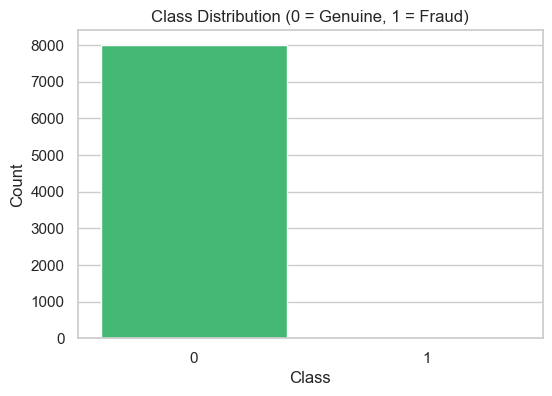

In [34]:
# EXPLORATORY DATA ANALYSIS
class_counts = df['Class'].value_counts()
print(class_counts)
print(f"\nFraud percentage: {class_counts[1] / len(df) * 100:.4f}%")

plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df, palette=['#2ecc71', '#e74c3c'])
plt.title("Class Distribution (0 = Genuine, 1 = Fraud)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

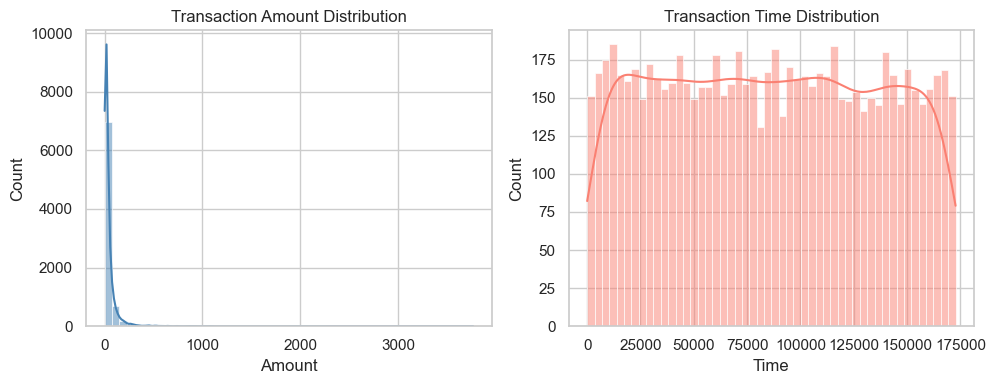

In [15]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(df['Amount'], bins=50, kde=True, color='steelblue')
plt.title("Transaction Amount Distribution")

plt.subplot(1,2,2)
sns.histplot(df['Time'], bins=50, kde=True, color='salmon')
plt.title("Transaction Time Distribution")
plt.tight_layout()
plt.show()


In [16]:
# Preprocessing
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])

df_model = df.drop(['Amount', 'Time'], axis=1)

X = df_model.drop('Class', axis=1)
y = df_model['Class']

print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (8040, 30)
Target shape: (8040,)


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, " Fraud cases:", y_train.sum())
print("Test shape:", X_test.shape, " Fraud cases:", y_test.sum())


Train shape: (6432, 30)  Fraud cases: 32
Test shape: (1608, 30)  Fraud cases: 8


In [20]:
 # Handling Class Imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_res.value_counts().to_dict())

Before SMOTE: {0: 6400, 1: 32}
After SMOTE: {0: 6400, 1: 6400}


In [21]:
# model training and evalation
results = {}

def evaluate_model(name, model, X_test, y_test, y_prob=None):
    y_pred = model.predict(X_test)
    if y_prob is None:
        y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    print(f"===== {name} =====")
    print(classification_report(y_test, y_pred, target_names=['Genuine', 'Fraud']))
    print(f"ROC-AUC: {auc:.4f}\n")

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Genuine','Fraud'], yticklabels=['Genuine','Fraud'])
    plt.title(f"{name} - Confusion Matrix")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()

    results[name] = {'accuracy': acc, 'f1': f1, 'roc_auc': auc, 'model': model}
    return y_prob

===== Logistic Regression =====
              precision    recall  f1-score   support

     Genuine       1.00      0.80      0.89      1600
       Fraud       0.01      0.25      0.01         8

    accuracy                           0.80      1608
   macro avg       0.50      0.53      0.45      1608
weighted avg       0.99      0.80      0.89      1608

ROC-AUC: 0.6130



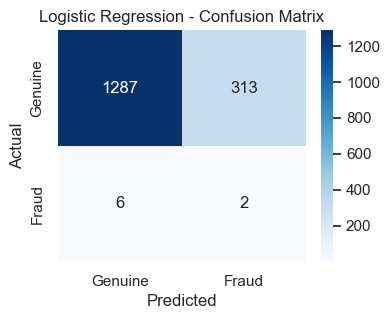

In [22]:
# logistic regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_res, y_train_res)

lr_prob = evaluate_model("Logistic Regression", log_reg, X_test, y_test)

===== Random Forest =====
              precision    recall  f1-score   support

     Genuine       0.99      0.99      0.99      1600
       Fraud       0.00      0.00      0.00         8

    accuracy                           0.99      1608
   macro avg       0.50      0.50      0.50      1608
weighted avg       0.99      0.99      0.99      1608

ROC-AUC: 0.7375



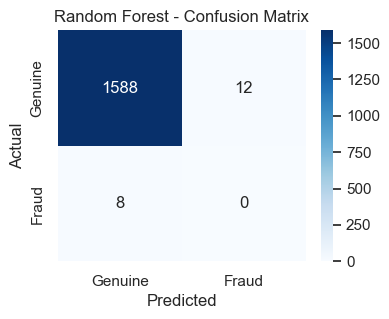

In [23]:
# Random forest
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train_res, y_train_res)

rf_prob = evaluate_model("Random Forest", rf, X_test, y_test)

===== XGBoost =====
              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00      1600
       Fraud       0.17      0.12      0.14         8

    accuracy                           0.99      1608
   macro avg       0.58      0.56      0.57      1608
weighted avg       0.99      0.99      0.99      1608

ROC-AUC: 0.7981



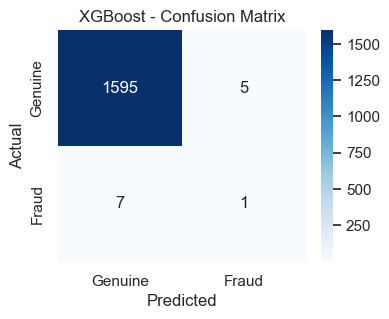

In [24]:
# XG Boost
xgb = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    use_label_encoder=False, eval_metric='logloss', random_state=42
)
xgb.fit(X_train_res, y_train_res)

xgb_prob = evaluate_model("XGBoost", xgb, X_test, y_test)

In [26]:
# neural network
nn_model = models.Sequential([
    layers.Input(shape=(X_train_res.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

nn_model.compile(optimizer='adam', loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

nn_model.summary()
history = nn_model.fit(
    X_train_res, y_train_res,
    validation_split=0.1,
    epochs=15,
    batch_size=256,
    verbose=1
)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.6924 - auc: 0.7572 - loss: 0.5831 - val_accuracy: 0.8734 - val_auc: 0.0000e+00 - val_loss: 0.4003
Epoch 2/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8424 - auc: 0.9213 - loss: 0.3669 - val_accuracy: 0.9633 - val_auc: 0.0000e+00 - val_loss: 0.1625
Epoch 3/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9017 - auc: 0.9670 - loss: 0.2393 - val_accuracy: 0.9922 - val_auc: 0.0000e+00 - val_loss: 0.0798
Epoch 4/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9360 - auc: 0.9838 - loss: 0.1659 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.0393
Epoch 5/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9536 - auc: 0.9909 - loss: 0.1219 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.0185
Epoch 6/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9685 - auc: 0.9958 - loss: 0.0827 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.0103
Epoch 7/15
45/45 ━━━━━━━━

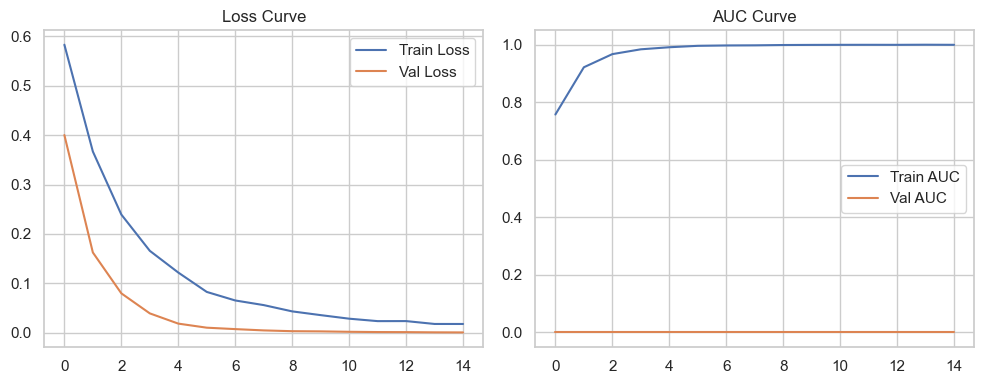

In [27]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Val AUC')
plt.title("AUC Curve")
plt.legend()
plt.tight_layout()
plt.show()


51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
===== Neural Network =====
              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00      1600
       Fraud       0.25      0.12      0.17         8

    accuracy                           0.99      1608
   macro avg       0.62      0.56      0.58      1608
weighted avg       0.99      0.99      0.99      1608

ROC-AUC: 0.5378


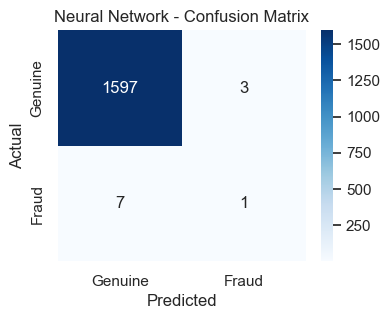

In [28]:
nn_pred_prob = nn_model.predict(X_test).ravel()
nn_pred = (nn_pred_prob >= 0.5).astype(int)

print("===== Neural Network =====")
print(classification_report(y_test, nn_pred, target_names=['Genuine', 'Fraud']))
nn_auc = roc_auc_score(y_test, nn_pred_prob)
print(f"ROC-AUC: {nn_auc:.4f}")

cm = confusion_matrix(y_test, nn_pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Genuine','Fraud'], yticklabels=['Genuine','Fraud'])
plt.title("Neural Network - Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

results['Neural Network'] = {
    'accuracy': accuracy_score(y_test, nn_pred),
    'f1': f1_score(y_test, nn_pred),
    'roc_auc': nn_auc,
    'model': nn_model
}


                     Accuracy  F1 Score   ROC-AUC
XGBoost              0.992537  0.142857  0.798125
Random Forest        0.987562  0.000000  0.737500
Logistic Regression  0.801617  0.012384  0.613047
Neural Network       0.993781  0.166667  0.537813


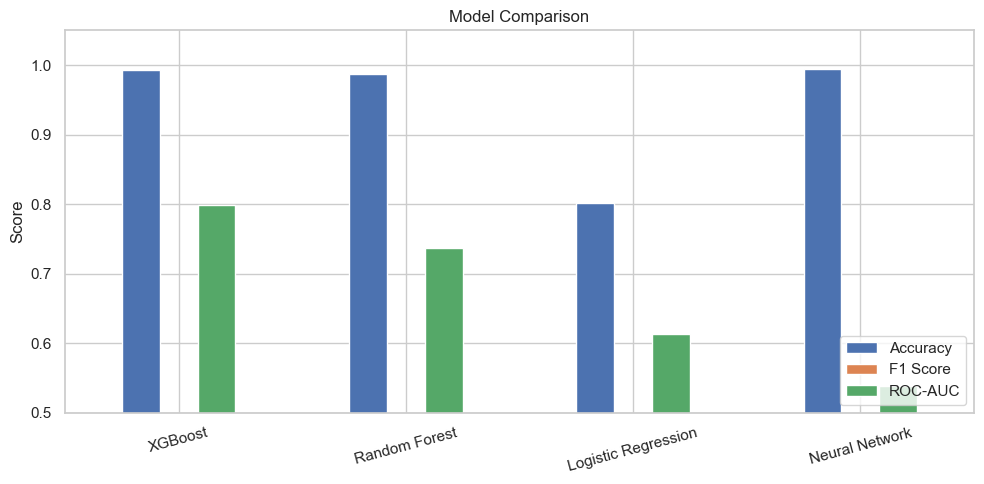

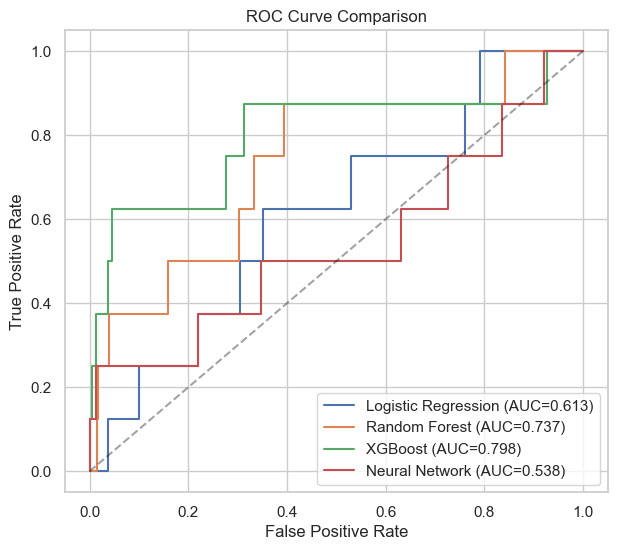

In [30]:
comparison_df = pd.DataFrame({
    name: {'Accuracy': v['accuracy'], 'F1 Score': v['f1'], 'ROC-AUC': v['roc_auc']}
    for name, v in results.items()
}).T

comparison_df = comparison_df.sort_values('ROC-AUC', ascending=False)
print(comparison_df)

comparison_df[['Accuracy','F1 Score','ROC-AUC']].plot(kind='bar', figsize=(10,5))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.ylim(0.5, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()
roc_data = {
    'Logistic Regression': lr_prob,
    'Random Forest': rf_prob,
    'XGBoost': xgb_prob,
    'Neural Network': nn_pred_prob
}

plt.figure(figsize=(7,6))
for name, prob in roc_data.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1],[0,1],'k--', alpha=0.4)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [31]:
best_classical_name = comparison_df.drop('Neural Network', errors='ignore').index[0]
best_classical_model = results[best_classical_name]['model']
print(f"Best classical model: {best_classical_name}")

joblib.dump(best_classical_model, "best_classical_model.pkl")
joblib.dump(log_reg, "logistic_regression_model.pkl")
joblib.dump(rf, "random_forest_model.pkl")
joblib.dump(xgb, "xgboost_model.pkl")
joblib.dump(scaler, "scaler.pkl")

nn_model.save("neural_network_model.keras")

print("\nAll models saved successfully:")
print("- best_classical_model.pkl  (auto-selected best classical model)")
print("- logistic_regression_model.pkl")
print("- random_forest_model.pkl")
print("- xgboost_model.pkl")
print("- neural_network_model.keras")
print("- scaler.pkl  (for scaling Amount/Time on new inputs)")

Best classical model: XGBoost

All models saved successfully:
- best_classical_model.pkl  (auto-selected best classical model)
- logistic_regression_model.pkl
- random_forest_model.pkl
- xgboost_model.pkl
- neural_network_model.keras
- scaler.pkl  (for scaling Amount/Time on new inputs)
